# EIP-8038 SLOAD/SSTORE Model Fit Investigation

The fitted NNLS models for SLOAD and SSTORE from the `estimate_8038_repricings.py` pipeline produce poor fits.
This notebook investigates whether the problem lies in the **benchmarks** or in the **processing/modeling code**.

**Two benchmark test types** are available for SLOAD/SSTORE:
1. `test_storage_sload_benchmark` / `test_sstore_variants` — parametric benchmarks using `access_warm` flag
2. `test_storage_access_*` — separate cold/warm test variants (e.g., `test_storage_access_cold_sload`)

We investigate both.

In [9]:
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import linregress

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2", rc={"figure.dpi": 150, "axes.titlesize": 13})

# Directories
repo_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
src_dir = os.path.join(repo_dir, "src")
sys.path.append(src_dir)

from data import extract_param_values

In [10]:
# Load the exported data
data_dir = os.path.join(repo_dir, "reports", "eip-8038", "runtime_estimation", "2026-01-26_2026-02-19")

mainnet_df = pd.read_csv(os.path.join(data_dir, "gas_bench_data_mainnet.csv"))
devnet_df = pd.read_csv(os.path.join(data_dir, "gas_bench_data_perf_devnet_2.csv"))
results_df = pd.read_csv(os.path.join(data_dir, "results_mainnet.csv"))

print(f"Mainnet: {len(mainnet_df)} rows, Devnet: {len(devnet_df)} rows")
print(f"Unique opcodes: {mainnet_df['test_opcode'].nunique()}")

Mainnet: 194742 rows, Devnet: 193542 rows
Unique opcodes: 159


## 1. Data Overview: SLOAD and SSTORE across all test types

In [11]:
# All SLOAD and SSTORE rows
sload_df = mainnet_df[mainnet_df["test_opcode"] == "SLOAD"].copy()
sstore_df = mainnet_df[mainnet_df["test_opcode"] == "SSTORE"].copy()

for label, df in [("SLOAD", sload_df), ("SSTORE", sstore_df)]:
    print(f"=== {label} ===")
    print(f"Total rows: {len(df)}")
    print(f"Test names: {sorted(df['test_name'].unique())}")
    print(f"Clients: {df['client_name'].value_counts().to_dict()}")
    for tn in sorted(df["test_name"].unique()):
        sub = df[df["test_name"] == tn]
        print(f"  {tn}: {len(sub)} rows, params={sorted(sub['test_params'].dropna().unique())}")
        print(f"    opcount: {sub['opcount'].min():.0f}-{sub['opcount'].max():.0f} (NaN: {sub['opcount'].isna().sum()})")
    print()

=== SLOAD ===
Total rows: 1600
Test names: ['test_storage_sload_benchmark']
Clients: {'besu': 720, 'nethermind': 720, 'geth': 160}
  test_storage_sload_benchmark: 1600 rows, params=['cold_0', 'cold_1']
    opcount: 14038-147282 (NaN: 0)

=== SSTORE ===
Total rows: 6470
Test names: ['test_sstore_variants']
Clients: {'besu': 2880, 'nethermind': 2880, 'geth': 710}
  test_sstore_variants: 6470 rows, params=['new_0-update_0-cold_0', 'new_0-update_0-cold_1', 'new_0-update_1-cold_0', 'new_0-update_1-cold_1', 'new_1-update_0-cold_0', 'new_1-update_0-cold_1', 'new_1-update_1-cold_0', 'new_1-update_1-cold_1']
    opcount: 1353-146921 (NaN: 0)



In [12]:
# Identify which tests are "storage_access" vs the parametric benchmarks
has_storage_access = mainnet_df["test_name"].str.contains("test_storage_access", na=False).any()
print(f"test_storage_access present in data: {has_storage_access}")

if has_storage_access:
    sa_df = mainnet_df[mainnet_df["test_name"].str.contains("test_storage_access", na=False)].copy()
    print(f"\ntest_storage_access rows: {len(sa_df)}")
    print(f"Unique test_names: {sorted(sa_df['test_name'].unique())}")
    print(f"Opcodes: {sorted(sa_df['test_opcode'].dropna().unique())}")
    print(f"Clients: {sa_df['client_name'].value_counts().to_dict()}")
    print(f"\nSample test_titles:")
    for tn in sorted(sa_df["test_name"].unique())[:4]:
        sample = sa_df[sa_df["test_name"] == tn]["test_title"].iloc[0]
        print(f"  {tn}: {sample[:120]}...")
else:
    print("\n** test_storage_access NOT found. You need to:")
    print("   1. Remove the filter in data.py line 91")
    print("   2. Re-run estimate_8038_repricings.py **")

test_storage_access present in data: False

** test_storage_access NOT found. You need to:
   1. Remove the filter in data.py line 91
   2. Re-run estimate_8038_repricings.py **


## 2. test_storage_access: Does it provide cold/warm differentiation?

The `test_storage_access` tests come in explicit cold/warm variants via the **test name**
(e.g., `test_storage_access_cold_sload` vs `test_storage_access_warm_sload`),
whereas `test_storage_sload_benchmark` uses an `access_warm` flag.

This section checks whether the `test_storage_access` tests produce the expected ~21x
opcount ratio between cold and warm SLOAD.

In [13]:
def analyze_cold_warm_opcounts(df, opcode_label):
    """Analyze cold/warm opcount ratios for a given opcode subset."""
    op_df = df[df["test_opcode"] == opcode_label].copy()
    if len(op_df) == 0:
        print(f"No {opcode_label} data found.")
        return None

    # Extract cold param
    op_df["cold"] = op_df["test_params"].apply(lambda x: extract_param_values(str(x), "cold"))
    
    # Show opcounts by test_name, cold, and block_limit
    for tn in sorted(op_df["test_name"].unique()):
        tn_df = op_df[op_df["test_name"] == tn]
        print(f"\n--- {tn} ({opcode_label}) ---")
        opcounts = tn_df[["cold", "block_limit_million", "opcount"]].drop_duplicates()
        
        for cold_val in sorted(opcounts["cold"].dropna().unique()):
            sub = opcounts[opcounts["cold"] == cold_val].sort_values("opcount")
            label = "warm" if cold_val == "0" else "cold"
            print(f"  cold={cold_val} ({label}): opcount {sub['opcount'].min():.0f} - {sub['opcount'].max():.0f} "
                  f"({sub['opcount'].nunique()} unique, NaN: {tn_df[tn_df['cold']==cold_val]['opcount'].isna().sum()})")
        
        # Compute ratio if both variants exist
        c0 = opcounts[opcounts["cold"] == "0"]["opcount"].dropna()
        c1 = opcounts[opcounts["cold"] == "1"]["opcount"].dropna()
        if len(c0) > 0 and len(c1) > 0:
            ratio = c0.max() / c1.max()
            gas_warm = 300e6 / c0.max() if c0.max() > 0 else np.nan
            gas_cold = 300e6 / c1.max() if c1.max() > 0 else np.nan
            print(f"  Max opcount ratio (warm/cold): {ratio:.2f}x (expected ~21x)")
            print(f"  Implied gas/op: warm={gas_warm:.0f}, cold={gas_cold:.0f}")
    return op_df

print("=" * 60)
print("SLOAD opcount analysis by test type")
print("=" * 60)
sload_analyzed = analyze_cold_warm_opcounts(mainnet_df[mainnet_df["test_opcode"] == "SLOAD"], "SLOAD")

print("\n" + "=" * 60)
print("SSTORE opcount analysis by test type")
print("=" * 60)
sstore_analyzed = analyze_cold_warm_opcounts(mainnet_df[mainnet_df["test_opcode"] == "SSTORE"], "SSTORE")

SLOAD opcount analysis by test type

--- test_storage_sload_benchmark (SLOAD) ---
  cold=0 (warm): opcount 14725 - 147282 (10 unique, NaN: 0)
  cold=1 (cold): opcount 14038 - 140401 (10 unique, NaN: 0)
  Max opcount ratio (warm/cold): 1.05x (expected ~21x)
  Implied gas/op: warm=2037, cold=2137

SSTORE opcount analysis by test type

--- test_sstore_variants (SSTORE) ---
  cold=0 (warm): opcount 1358 - 146921 (67 unique, NaN: 0)
  cold=1 (cold): opcount 1353 - 134055 (64 unique, NaN: 0)
  Max opcount ratio (warm/cold): 1.10x (expected ~21x)
  Implied gas/op: warm=2042, cold=2238


## 3. test_storage_sload_benchmark: cold/warm variants are broken

The original SLOAD benchmark has `access_warm=True/False` mapped to `cold_0/cold_1`.
Both produce ~2100 gas/op opcounts instead of the expected 100 vs 2100 gas.

In [14]:
# Focus on test_storage_sload_benchmark
bench_sload = sload_df[sload_df["test_name"] == "test_storage_sload_benchmark"].copy()

if len(bench_sload) > 0:
    sload_opcounts = (
        bench_sload[["test_params", "block_limit_million", "opcount"]]
        .drop_duplicates()
        .sort_values(["block_limit_million", "test_params"])
    )
    cold_0 = sload_opcounts[sload_opcounts["test_params"] == "cold_0"].set_index("block_limit_million")["opcount"]
    cold_1 = sload_opcounts[sload_opcounts["test_params"] == "cold_1"].set_index("block_limit_million")["opcount"]

    comparison = pd.DataFrame({
        "cold_0 (warm) opcount": cold_0,
        "cold_1 (cold) opcount": cold_1,
        "ratio": cold_0 / cold_1,
        "gas_per_op_warm": cold_0.index.astype(float) * 1e6 / cold_0,
        "gas_per_op_cold": cold_1.index.astype(float) * 1e6 / cold_1,
    })
    comparison.index.name = "block_limit_M"

    print("test_storage_sload_benchmark: cold_0 vs cold_1 opcounts")
    print(f"Expected ratio (warm/cold): ~21x")
    print(f"Actual ratio: {comparison['ratio'].mean():.3f}x")
    print(f"Gas per op (warm): ~{comparison['gas_per_op_warm'].mean():.0f}, (cold): ~{comparison['gas_per_op_cold'].mean():.0f}")
    print(f"\nBoth at COLD pricing (~2100 gas). Warm benchmark NOT producing warm SLOADs.\n")
    display(comparison)
else:
    print("No test_storage_sload_benchmark data found.")

test_storage_sload_benchmark: cold_0 vs cold_1 opcounts
Expected ratio (warm/cold): ~21x
Actual ratio: 1.049x
Gas per op (warm): ~2037, (cold): ~2137

Both at COLD pricing (~2100 gas). Warm benchmark NOT producing warm SLOADs.



,cold_0 (warm) opcount,cold_1 (cold) opcount,ratio,gas_per_op_warm,gas_per_op_cold
block_limit_M,,,,,
30,14725.0,14038.0,1.048939,2037.351443,2137.056561
60,29451.0,28076.0,1.048974,2037.282265,2137.056561
90,44177.0,42114.0,1.048986,2037.259207,2137.056561
120,58903.0,56152.0,1.048992,2037.247678,2137.056561
150,73641.0,70200.0,1.049017,2036.908787,2136.752137
180,88367.0,84238.0,1.049016,2036.959498,2136.802868
210,103093.0,98276.0,1.049015,2036.995722,2136.839106
240,117819.0,112314.0,1.049014,2037.022891,2136.866286
270,132545.0,126353.0,1.049006,2037.044023,2136.870514


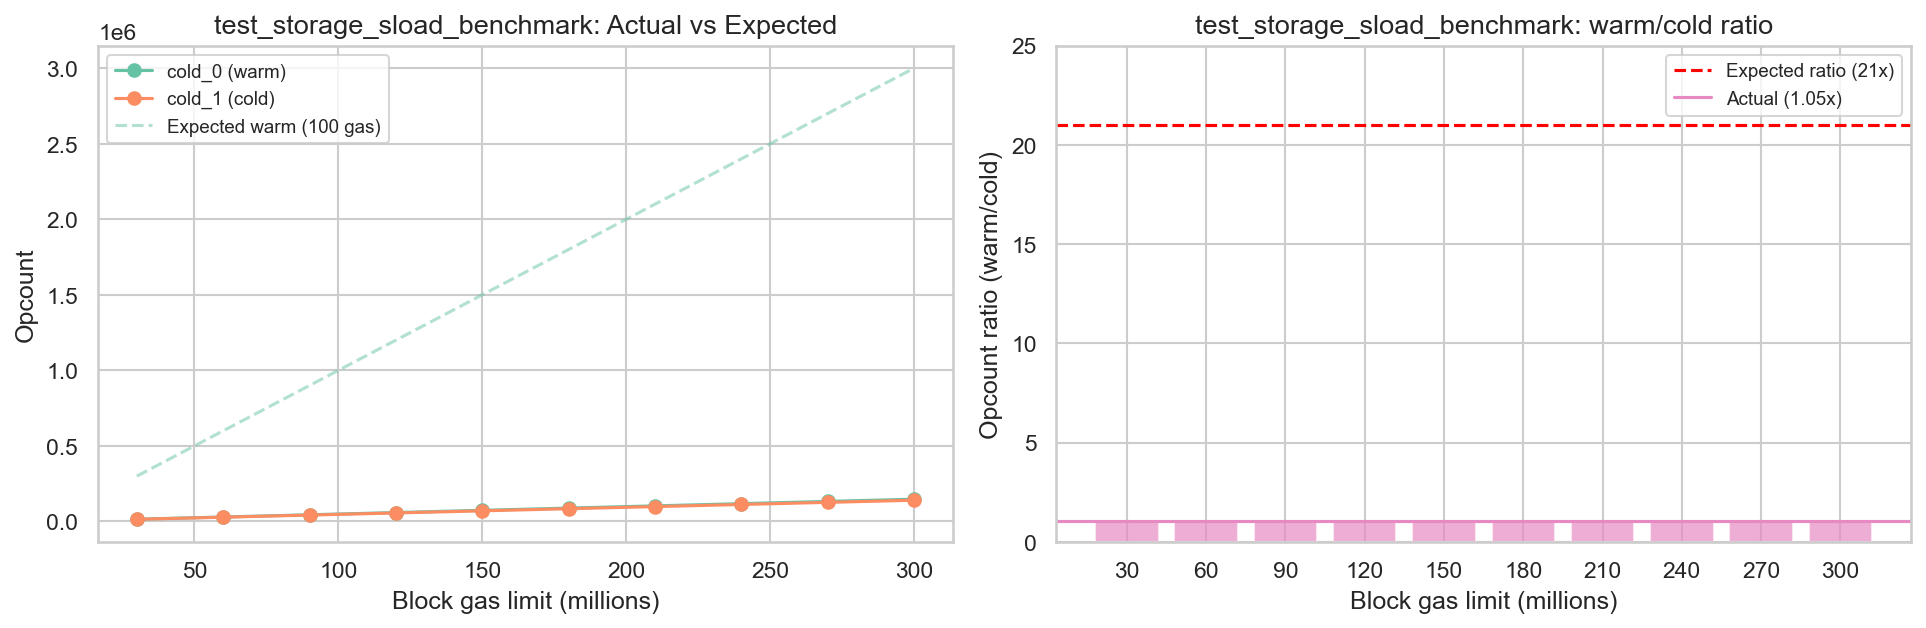

In [15]:
# Visualize: opcounts should diverge 21x but don't (benchmark test only)
if len(bench_sload) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    for params, color, label in [("cold_0", "C0", "cold_0 (warm)"), ("cold_1", "C1", "cold_1 (cold)")]:
        subset = sload_opcounts[sload_opcounts["test_params"] == params]
        ax.plot(subset["block_limit_million"].astype(float), subset["opcount"], "o-", color=color, label=label)
    expected_warm = cold_1.index.astype(float) * 1e6 / 100
    ax.plot(cold_1.index.astype(float), expected_warm, "--", color="C0", alpha=0.5, label="Expected warm (100 gas)")
    ax.set_xlabel("Block gas limit (millions)")
    ax.set_ylabel("Opcount")
    ax.set_title("test_storage_sload_benchmark: Actual vs Expected")
    ax.legend(fontsize=9)

    ax = axes[1]
    ax.bar(comparison.index.astype(str), comparison["ratio"], color="C3", alpha=0.7)
    ax.axhline(y=21, color="red", linestyle="--", label="Expected ratio (21x)")
    ax.axhline(y=comparison["ratio"].mean(), color="C3", linestyle="-",
               label=f"Actual ({comparison['ratio'].mean():.2f}x)")
    ax.set_xlabel("Block gas limit (millions)")
    ax.set_ylabel("Opcount ratio (warm/cold)")
    ax.set_title("test_storage_sload_benchmark: warm/cold ratio")
    ax.set_ylim(0, 25)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

## 4. Runtime patterns by test type and client

Compare runtime vs opcount for all SLOAD/SSTORE tests, colored by cold/warm.

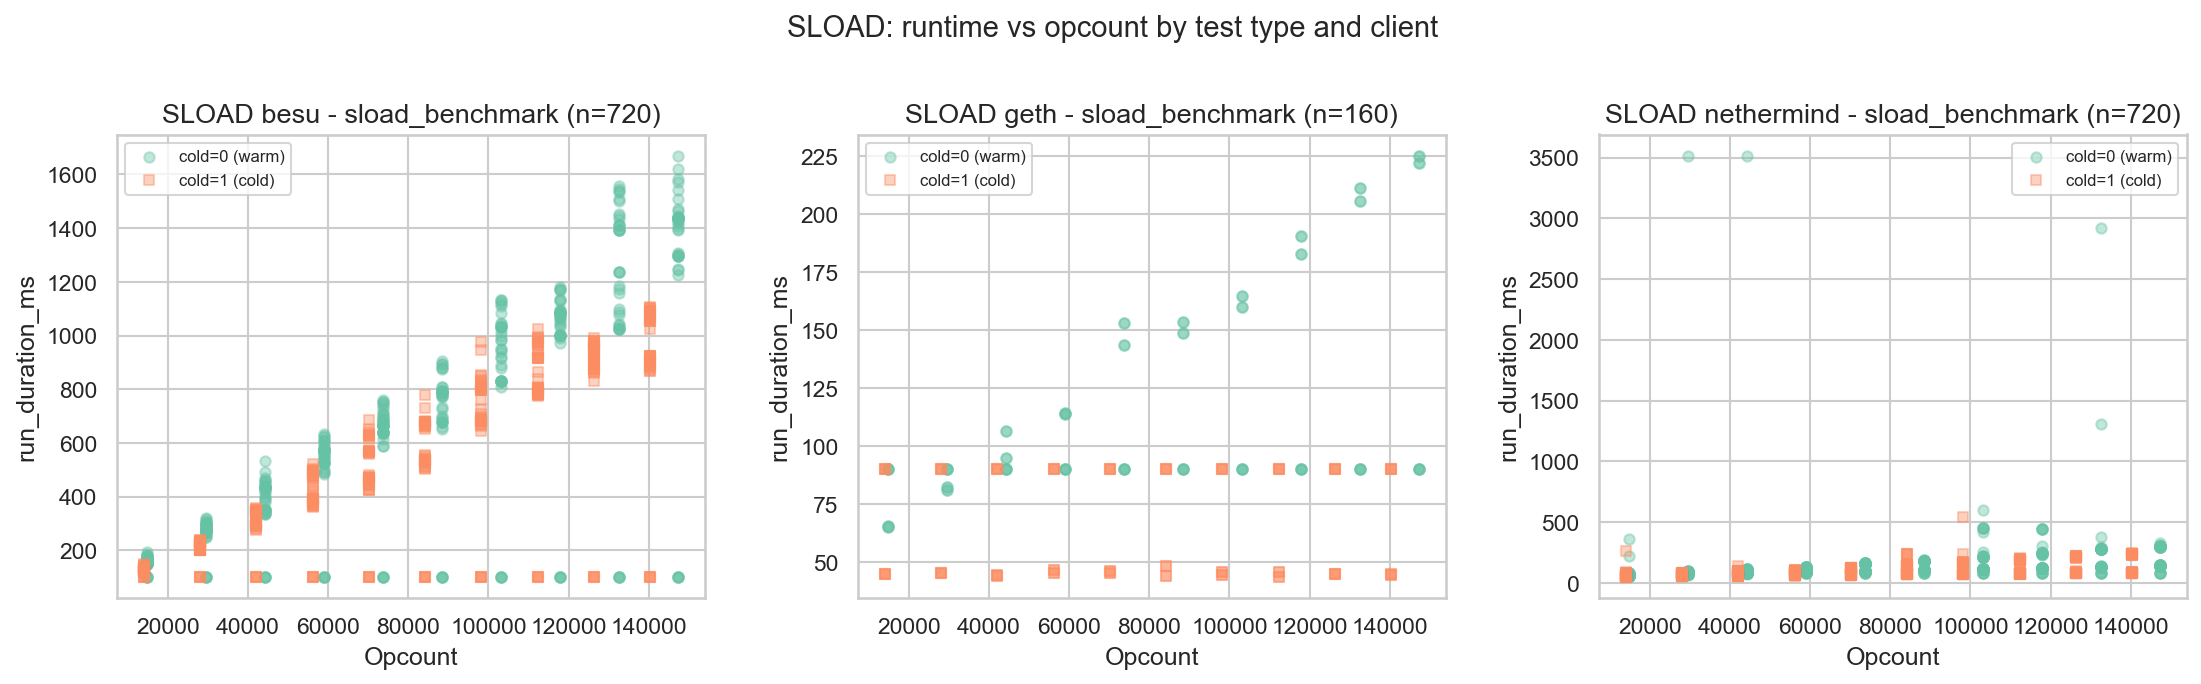

In [16]:
# SLOAD runtime by client, test_name, and cold/warm
sload_df["cold"] = sload_df["test_params"].apply(lambda x: extract_param_values(str(x), "cold"))
sload_df["cold_label"] = sload_df["cold"].map({"0": "warm", "1": "cold"})
sload_df["source"] = np.where(
    sload_df["test_name"].str.contains("test_storage_access", na=False),
    "test_storage_access", "benchmark"
)

clients = sorted(sload_df["client_name"].unique())
test_names = sorted(sload_df["test_name"].unique())
n_tests = len(test_names)

fig, axes = plt.subplots(n_tests, len(clients), figsize=(5 * len(clients), 4.5 * n_tests),
                          squeeze=False)

for row, tn in enumerate(test_names):
    for col, client in enumerate(clients):
        ax = axes[row][col]
        subset = sload_df[(sload_df["client_name"] == client) & (sload_df["test_name"] == tn)]
        for cold_val, color, marker in [("0", "C0", "o"), ("1", "C1", "s")]:
            pts = subset[subset["cold"] == cold_val]
            label_str = f"cold={cold_val} ({'warm' if cold_val == '0' else 'cold'})"
            ax.scatter(pts["opcount"], pts["run_duration_ms"],
                       c=color, marker=marker, alpha=0.4, s=25, label=label_str)
        ax.set_xlabel("Opcount")
        ax.set_ylabel("run_duration_ms")
        short_tn = tn.replace("test_storage_", "").replace("test_", "")
        ax.set_title(f"SLOAD {client} - {short_tn} (n={len(subset)})")
        ax.legend(fontsize=8)

plt.suptitle("SLOAD: runtime vs opcount by test type and client", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

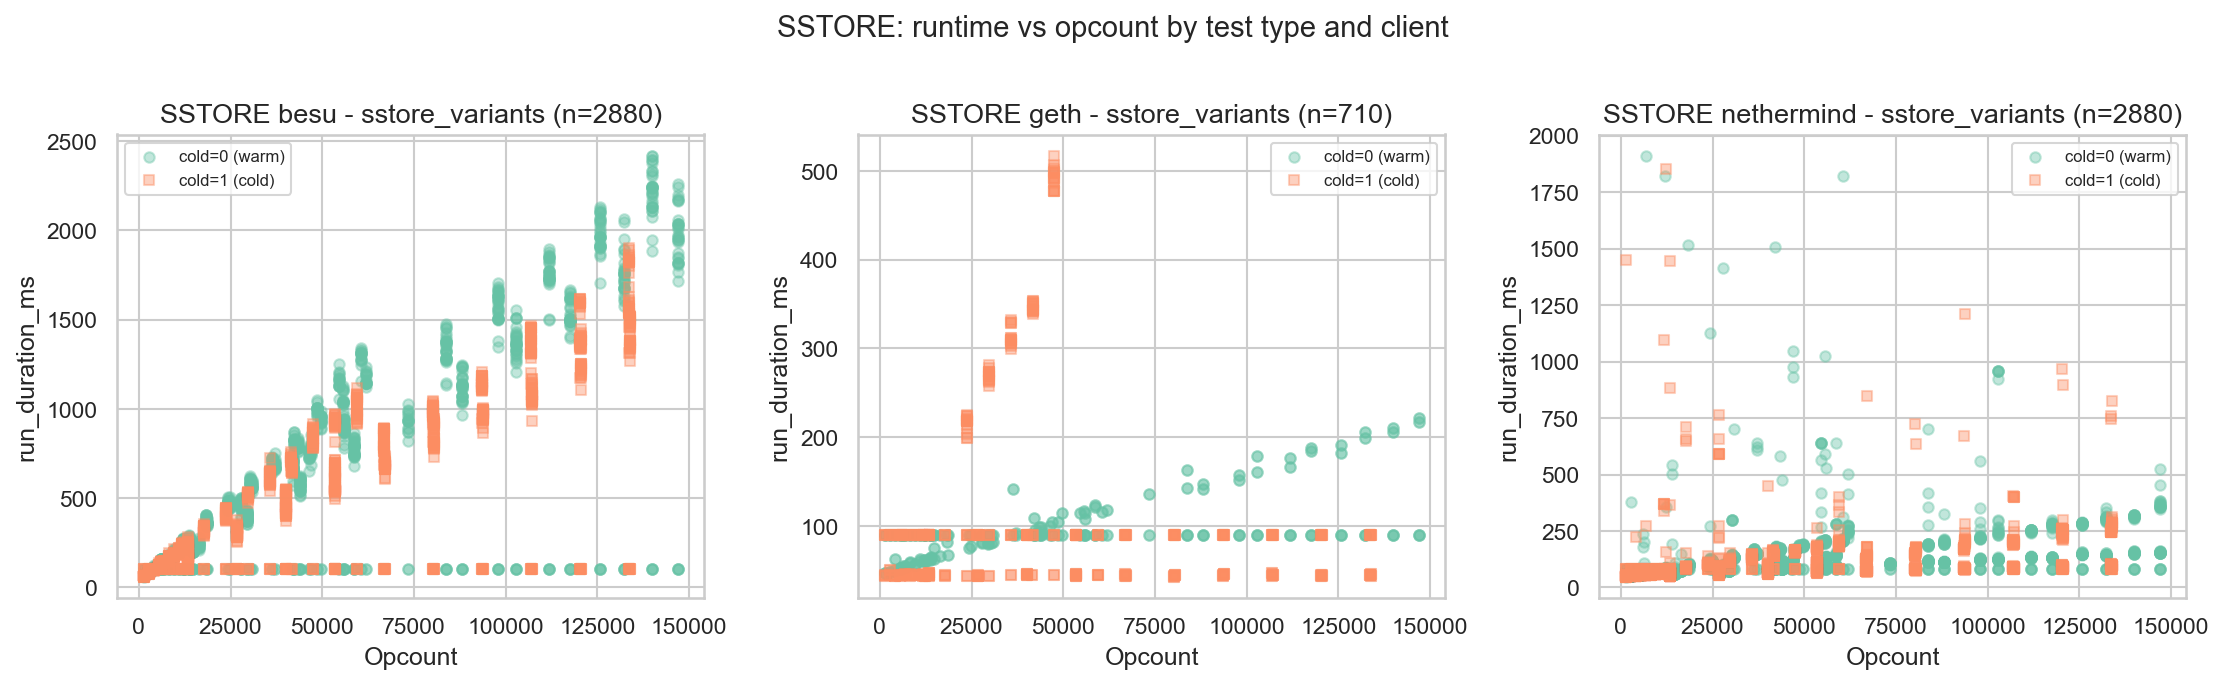

In [17]:
# SSTORE runtime by client, test_name, and cold/warm
sstore_df["cold"] = sstore_df["test_params"].apply(lambda x: extract_param_values(str(x), "cold"))
sstore_df["new"] = sstore_df["test_params"].apply(lambda x: extract_param_values(str(x), "new"))
sstore_df["update"] = sstore_df["test_params"].apply(lambda x: extract_param_values(str(x), "update"))
sstore_df["source"] = np.where(
    sstore_df["test_name"].str.contains("test_storage_access", na=False),
    "test_storage_access", "sstore_variants"
)

clients = sorted(sstore_df["client_name"].unique())
test_names = sorted(sstore_df["test_name"].unique())
n_tests = len(test_names)

fig, axes = plt.subplots(n_tests, len(clients), figsize=(5 * len(clients), 4.5 * n_tests),
                          squeeze=False)

for row, tn in enumerate(test_names):
    for col, client in enumerate(clients):
        ax = axes[row][col]
        subset = sstore_df[(sstore_df["client_name"] == client) & (sstore_df["test_name"] == tn)]
        for cold_val, color, marker in [("0", "C0", "o"), ("1", "C1", "s")]:
            pts = subset[subset["cold"] == cold_val]
            label_str = f"cold={cold_val} ({'warm' if cold_val == '0' else 'cold'})"
            ax.scatter(pts["opcount"], pts["run_duration_ms"],
                       c=color, marker=marker, alpha=0.4, s=25, label=label_str)
        ax.set_xlabel("Opcount")
        ax.set_ylabel("run_duration_ms")
        short_tn = tn.replace("test_storage_", "").replace("test_", "")
        ax.set_title(f"SSTORE {client} - {short_tn} (n={len(subset)})")
        ax.legend(fontsize=8)

plt.suptitle("SSTORE: runtime vs opcount by test type and client", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Geth SLOAD anomaly: cold_1 runtime is flat

For the benchmark test, geth cold_1 (cold) runtime is constant at ~67ms regardless of opcount.

In [18]:
# Flat runtime analysis for geth
geth_sload = sload_df[sload_df["client_name"] == "geth"]

for tn in sorted(geth_sload["test_name"].unique()):
    tn_df = geth_sload[geth_sload["test_name"] == tn]
    print(f"\n=== Geth SLOAD: {tn} ===")
    stats = (
        tn_df.groupby(["test_params", "opcount"])["run_duration_ms"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    for params in sorted(stats["test_params"].unique()):
        p_stats = stats[stats["test_params"] == params].sort_values("opcount")
        cold_val = extract_param_values(params, "cold")
        label = "warm" if cold_val == "0" else "cold"
        mean_range = f"{p_stats['mean'].min():.1f} - {p_stats['mean'].max():.1f}ms"
        std_of_means = p_stats["mean"].std()
        scaling = "FLAT" if std_of_means < 2.0 else "scales with opcount"
        print(f"  {params} ({label}): mean range={mean_range}, std_of_means={std_of_means:.2f}ms -> {scaling}")


=== Geth SLOAD: test_storage_sload_benchmark ===
  cold_0 (warm): mean range=77.6 - 156.8ms, std_of_means=26.65ms -> scales with opcount
  cold_1 (cold): mean range=67.1 - 68.1ms, std_of_means=0.32ms -> FLAT


## 6. SSTORE variant analysis

The SSTORE benchmark produces meaningfully different opcounts for `update` variants.
Let's check per-variant regression slopes.

In [19]:
# SSTORE opcounts by variant
sstore_opcount_summary = (
    sstore_df.groupby(["test_name", "test_params"])["opcount"]
    .agg(["min", "max", "nunique", "count"])
    .sort_values(["test_name", "max"], ascending=[True, False])
)
sstore_opcount_summary["implied_gas_per_op"] = (300e6 / sstore_opcount_summary["max"]).round(0)
print("SSTORE opcounts by test and variant:")
display(sstore_opcount_summary)

SSTORE opcounts by test and variant:


min       max  nunique  count  \
test_name            test_params                                                
test_sstore_variants new_1-update_0-cold_0  13978.0  146921.0       20    800   
                     new_0-update_0-cold_0  13978.0  146920.0       20    800   
                     new_1-update_0-cold_1  13373.0  134055.0       20    800   
                     new_0-update_0-cold_1  13373.0  134054.0       20    800   
                     new_0-update_1-cold_0   6063.0   61958.0       20    800   
                     new_0-update_1-cold_1   5943.0   59506.0       20    870   
                     new_1-update_1-cold_0   1358.0   13657.0       20    800   
                     new_1-update_1-cold_1   1353.0   13535.0       18    800   

                                            implied_gas_per_op  
test_name            test_params                                
test_sstore_variants new_1-update_0-cold_0              2042.0  
                     new_0-update_0-cold_0              2042.0  
                     new_1-update_0-cold_1              2238.0  
                     new_0-update_0-cold_1              2238.0  
                     new_0-update_1-cold_0              4842.0  
                     new_0-update_1-cold_1              5042.0  
                     new_1-update_1-cold_0             21967.0  
                     new_1-update_1-cold_1             22165.0

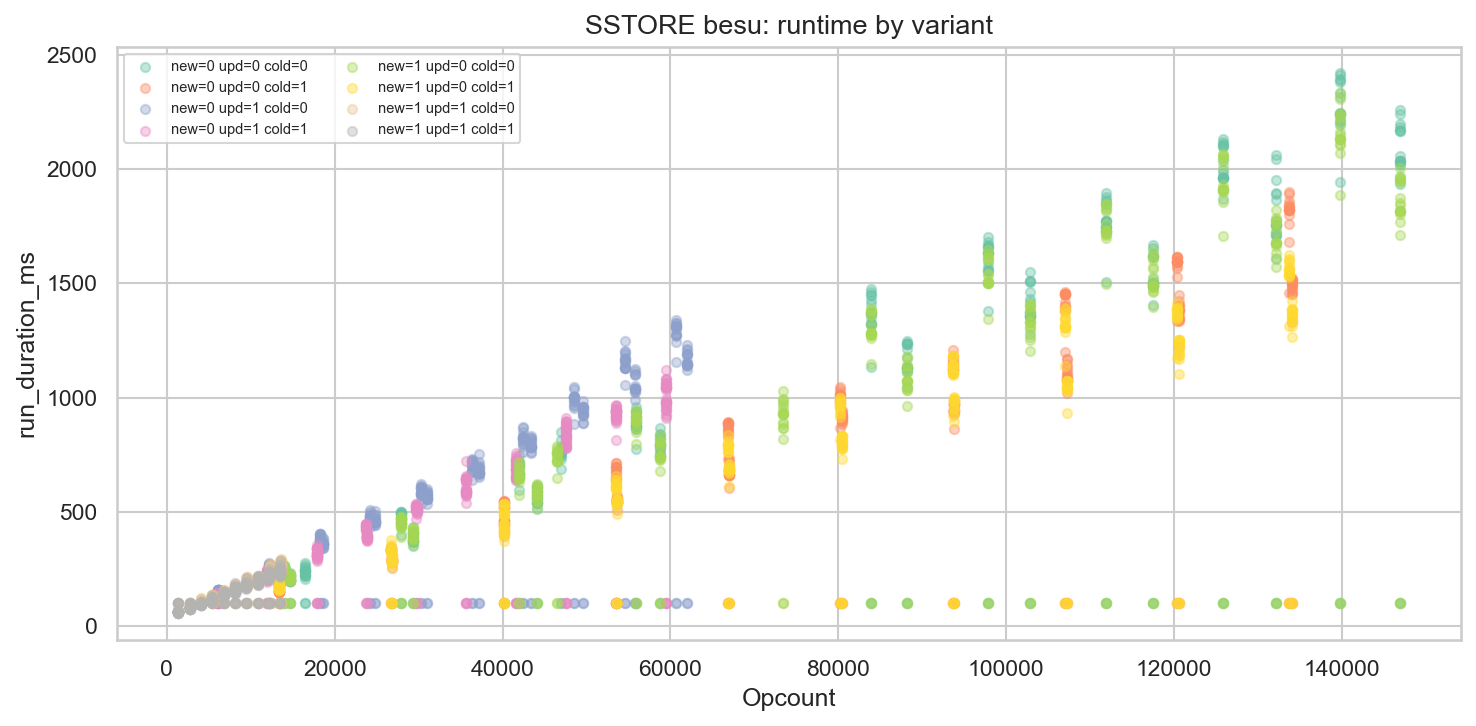


Besu SSTORE: per-variant linear regression
Variant                                   Slope (ms/op)       R²     n
---------------------------------------------------------------------------
new=0 upd=0 cold=0                             0.013136    0.676   360
new=0 upd=0 cold=1                             0.010742    0.654   360
new=0 upd=1 cold=0                             0.017345    0.675   360
new=0 upd=1 cold=1                             0.014864    0.678   360
new=1 upd=0 cold=0                             0.012189    0.637   360
new=1 upd=0 cold=1                             0.009435    0.645   360
new=1 upd=1 cold=0                             0.014169    0.791   360
new=1 upd=1 cold=1                             0.013218    0.806   360

Different variants have DIFFERENT slopes -> parameter effects exist.


In [20]:
# Per-variant slopes for besu (cleanest client)
besu_sstore = sstore_df[sstore_df["client_name"] == "besu"].dropna(subset=["opcount"]).copy()

if len(besu_sstore) > 0:
    besu_sstore["variant"] = (
        "new=" + besu_sstore["new"].fillna("?") +
        " upd=" + besu_sstore["update"].fillna("?") +
        " cold=" + besu_sstore["cold"].fillna("?")
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    for variant in sorted(besu_sstore["variant"].unique()):
        subset = besu_sstore[besu_sstore["variant"] == variant]
        ax.scatter(subset["opcount"], subset["run_duration_ms"], alpha=0.4, s=20, label=variant)
    ax.set_xlabel("Opcount")
    ax.set_ylabel("run_duration_ms")
    ax.set_title("SSTORE besu: runtime by variant")
    ax.legend(fontsize=7, ncol=2, loc="upper left")
    plt.tight_layout()
    plt.show()

    print("\nBesu SSTORE: per-variant linear regression")
    print(f"{'Variant':<40} {'Slope (ms/op)':>14} {'R\u00b2':>8} {'n':>5}")
    print("-" * 75)
    for variant in sorted(besu_sstore["variant"].unique()):
        subset = besu_sstore[besu_sstore["variant"] == variant].dropna(subset=["opcount", "run_duration_ms"])
        if len(subset) > 2:
            slope, intercept, r, p, se = linregress(subset["opcount"], subset["run_duration_ms"])
            print(f"{variant:<40} {slope:>14.6f} {r**2:>8.3f} {len(subset):>5}")
    print("\nDifferent variants have DIFFERENT slopes -> parameter effects exist.")

## 7. Noise analysis: Nethermind outliers and Geth data scarcity

In [21]:
# Data availability
print("=== Observations per client ===")
for op_name, op_df in [("SLOAD", sload_df), ("SSTORE", sstore_df)]:
    print(f"\n{op_name}:")
    counts = op_df["client_name"].value_counts()
    timestamps = op_df.groupby("client_name")["ingestion_timestamp"].nunique()
    nan_counts = op_df.groupby("client_name")["opcount"].apply(lambda x: x.isna().sum())
    for client in sorted(counts.index):
        print(f"  {client}: {counts[client]} rows, {timestamps[client]} timestamps, "
              f"{nan_counts[client]} NaN opcounts")

=== Observations per client ===

SLOAD:
  besu: 720 rows, 17 timestamps, 0 NaN opcounts
  geth: 160 rows, 3 timestamps, 0 NaN opcounts
  nethermind: 720 rows, 17 timestamps, 0 NaN opcounts

SSTORE:
  besu: 2880 rows, 17 timestamps, 0 NaN opcounts
  geth: 710 rows, 17 timestamps, 0 NaN opcounts
  nethermind: 2880 rows, 17 timestamps, 0 NaN opcounts


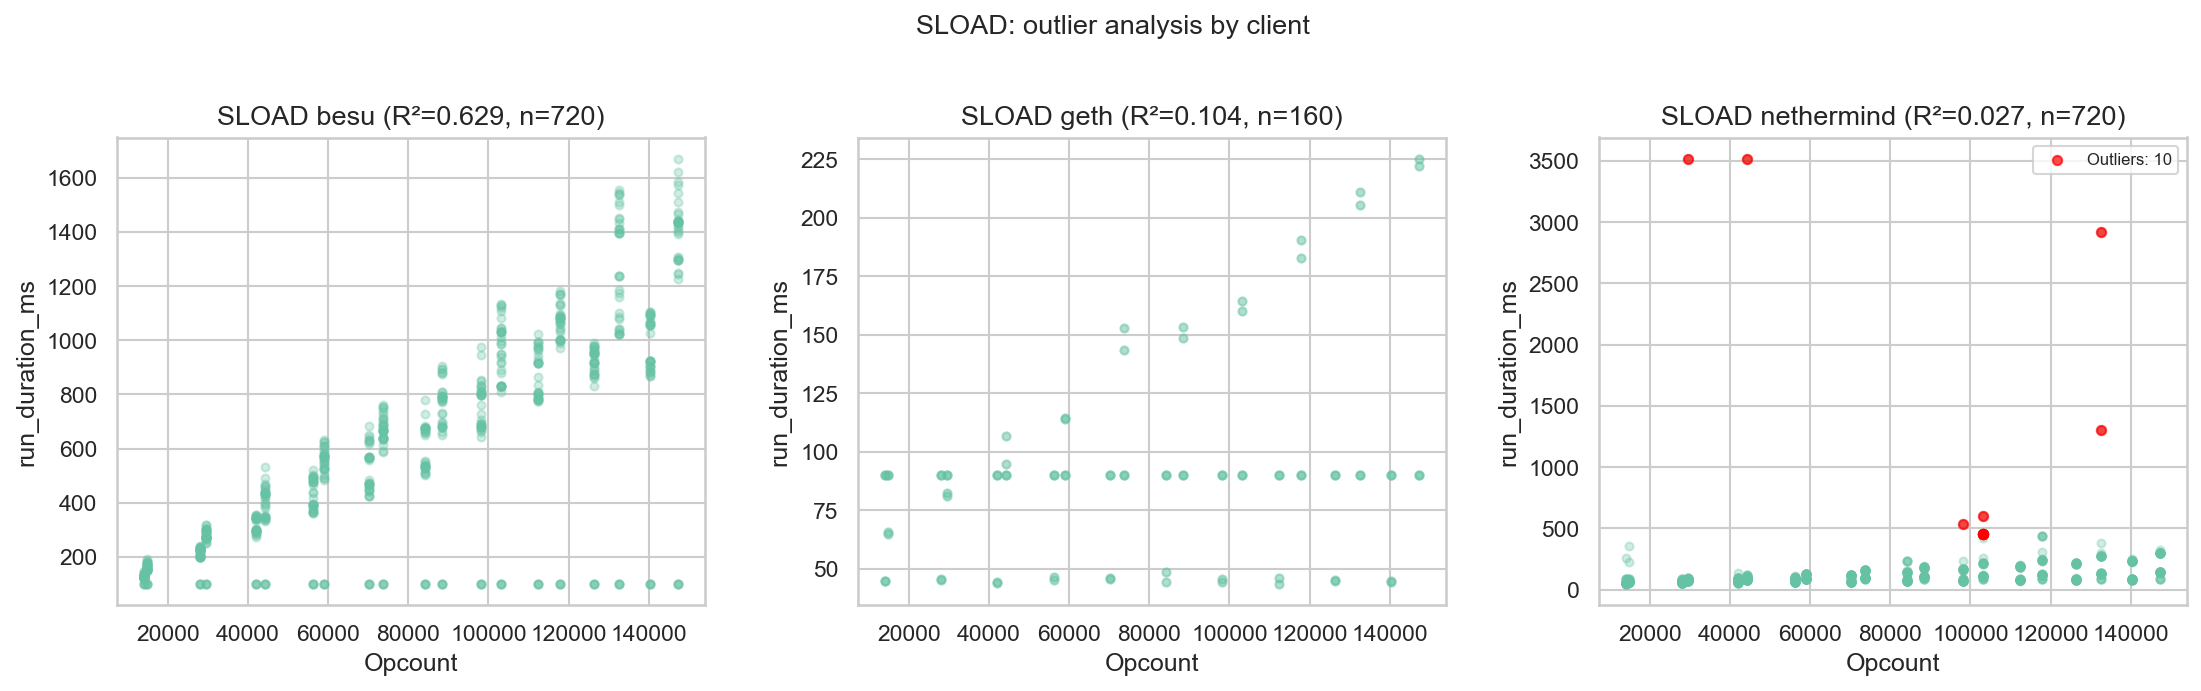

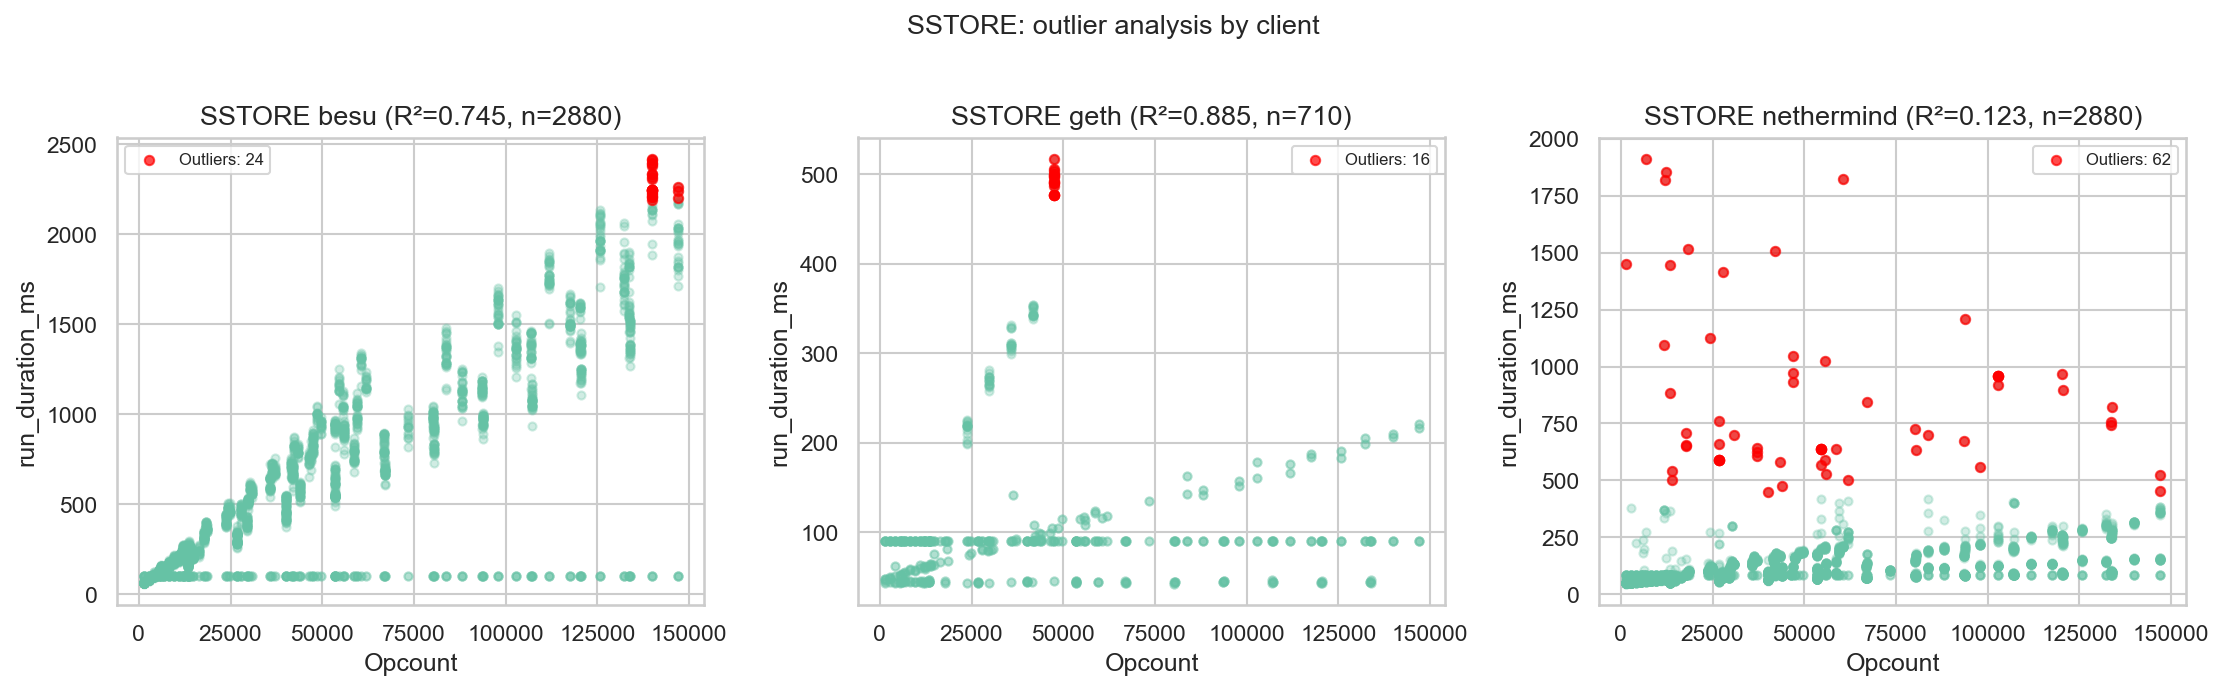

In [22]:
# Outlier analysis across all clients
for op_name, op_df in [("SLOAD", sload_df), ("SSTORE", sstore_df)]:
    clients = sorted(op_df["client_name"].unique())
    fig, axes = plt.subplots(1, len(clients), figsize=(5 * len(clients), 4.5))
    if len(clients) == 1:
        axes = [axes]

    for i, client in enumerate(clients):
        ax = axes[i]
        client_df = op_df[op_df["client_name"] == client].dropna(subset=["opcount"])
        ax.scatter(client_df["opcount"], client_df["run_duration_ms"], alpha=0.3, s=15)

        median_rt = client_df["run_duration_ms"].median()
        outliers = client_df[client_df["run_duration_ms"] > 5 * median_rt]
        if len(outliers) > 0:
            ax.scatter(outliers["opcount"], outliers["run_duration_ms"],
                       c="red", s=20, alpha=0.7, label=f"Outliers: {len(outliers)}")

        r2_vals = results_df[(results_df["client"] == client) & (results_df["opcode"] == op_name)]["rsquared"]
        r2_str = f"R\u00b2={r2_vals.values[0]:.3f}" if len(r2_vals) > 0 else ""
        ax.set_xlabel("Opcount")
        ax.set_ylabel("run_duration_ms")
        ax.set_title(f"{op_name} {client} ({r2_str}, n={len(client_df)})")
        if len(outliers) > 0:
            ax.legend(fontsize=8)

    plt.suptitle(f"{op_name}: outlier analysis by client", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## 8. Model Results

In [23]:
# Current model results
display_cols = ["opcode", "client", "nobs", "rsquared", "rsquared_adj", "intercept", "slope", "slope_pvalue"]
param_cols = [c for c in results_df.columns if any(p in c for p in ["new", "cold", "update"]) and "conf" not in c]
display_cols += param_cols
display_cols = [c for c in display_cols if c in results_df.columns]

print("=== Model results for SLOAD and SSTORE ===")
display(results_df[display_cols].round(4))

=== Model results for SLOAD and SSTORE ===


,opcode,client,nobs,rsquared,rsquared_adj,intercept,slope,slope_pvalue,new,new_pvalue,cold,cold_pvalue,update,update_pvalue
0,SSTORE,geth,70,0.8851,0.8780,0.0000,0.0093,0.0,0.0,1.0,0.0,1.0,0.0000,1.0
1,SSTORE,nethermind,2880,0.1227,0.1215,61.2659,0.0011,0.0,0.0,1.0,0.0,1.0,0.0016,0.0
2,SSTORE,besu,2880,0.7446,0.7442,22.5243,0.0115,0.0,0.0,1.0,0.0,1.0,0.0047,0.0
3,SLOAD,geth,160,0.1043,0.0929,65.6021,0.0003,0.0,NaN,NaN,0.0,1.0,NaN,NaN
4,SLOAD,nethermind,720,0.0271,0.0244,66.5406,0.0009,0.0,NaN,NaN,0.0,1.0,NaN,NaN
5,SLOAD,besu,720,0.6291,0.6281,14.2342,0.0075,0.0,NaN,NaN,0.0,1.0,NaN,NaN


## 9. Pipeline validation: EIP-7904 works perfectly

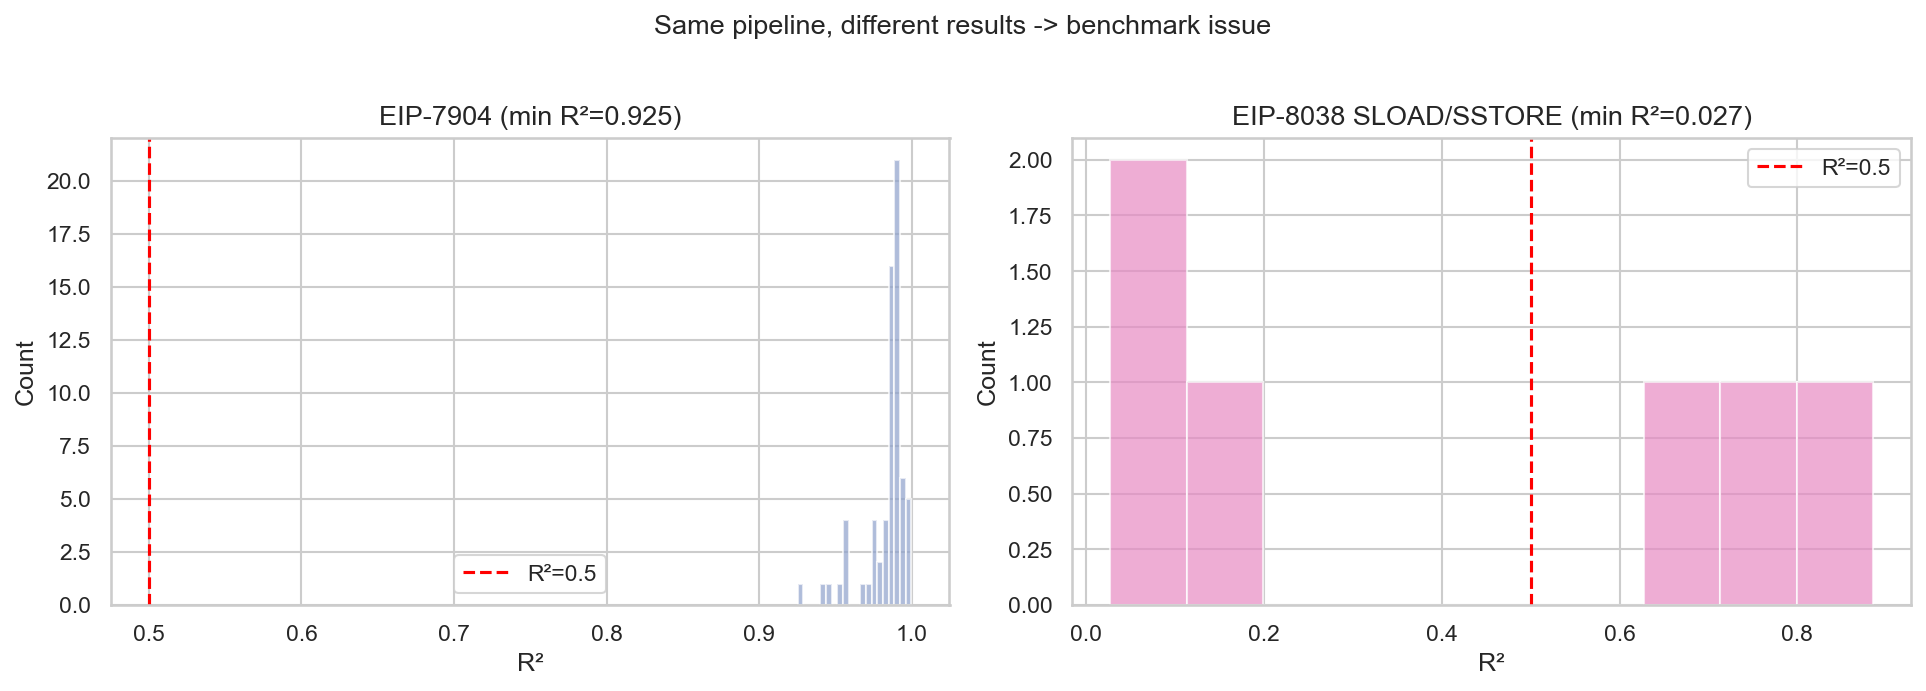

In [24]:
eip7904_results_path = os.path.join(
    repo_dir, "reports", "eip-7904", "runtime_estimation", "2026-01-15_2026-01-29", "results.csv"
)

if os.path.exists(eip7904_results_path):
    eip7904_df = pd.read_csv(eip7904_results_path)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    ax.hist(eip7904_df["rsquared"], bins=20, color="C2", alpha=0.7, edgecolor="white")
    ax.axvline(x=0.5, color="red", linestyle="--", label="R\u00b2=0.5")
    ax.set_xlabel("R\u00b2")
    ax.set_ylabel("Count")
    ax.set_title(f"EIP-7904 (min R\u00b2={eip7904_df['rsquared'].min():.3f})")
    ax.legend()

    ax = axes[1]
    ax.hist(results_df["rsquared"], bins=10, color="C3", alpha=0.7, edgecolor="white")
    ax.axvline(x=0.5, color="red", linestyle="--", label="R\u00b2=0.5")
    ax.set_xlabel("R\u00b2")
    ax.set_ylabel("Count")
    ax.set_title(f"EIP-8038 SLOAD/SSTORE (min R\u00b2={results_df['rsquared'].min():.3f})")
    ax.legend()

    plt.suptitle("Same pipeline, different results -> benchmark issue", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"EIP-7904 results not found at {eip7904_results_path}")
    print("From manual inspection: all EIP-7904 R\u00b2 values are 0.925-1.000.")

## 10. Devnet cross-validation

In [25]:
# Check if devnet shows same patterns
devnet_sload = devnet_df[devnet_df["test_opcode"] == "SLOAD"].copy()
devnet_sload["cold"] = devnet_sload["test_params"].apply(lambda x: extract_param_values(str(x), "cold"))

print("Devnet SLOAD test names:", sorted(devnet_sload["test_name"].unique()))
print()

for tn in sorted(devnet_sload["test_name"].unique()):
    tn_df = devnet_sload[devnet_sload["test_name"] == tn]
    opcounts = tn_df[["cold", "opcount"]].dropna().drop_duplicates()
    for cold_val in sorted(opcounts["cold"].unique()):
        sub = opcounts[opcounts["cold"] == cold_val]
        label = "warm" if cold_val == "0" else "cold"
        print(f"  {tn} cold={cold_val} ({label}): opcount {sub['opcount'].min():.0f}-{sub['opcount'].max():.0f}")
    c0_max = opcounts[opcounts["cold"] == "0"]["opcount"].max()
    c1_max = opcounts[opcounts["cold"] == "1"]["opcount"].max()
    if pd.notna(c0_max) and pd.notna(c1_max) and c1_max > 0:
        print(f"  -> Ratio: {c0_max/c1_max:.2f}x\n")

print("\nDevnet SLOAD median runtimes by client and params:")
print(devnet_sload.groupby(["client_name", "test_params"])["run_duration_ms"].median().unstack().to_string())

Devnet SLOAD test names: ['test_storage_sload_benchmark']

  test_storage_sload_benchmark cold=0 (warm): opcount 14725-147282
  test_storage_sload_benchmark cold=1 (cold): opcount 14038-140401
  -> Ratio: 1.05x


Devnet SLOAD median runtimes by client and params:
test_params     cold_0     cold_1
client_name                      
besu         729.70620  571.70710
geth         147.87615   44.76020
nethermind   122.19140   80.68725


## Summary of Findings

### Pipeline
The processing/modeling pipeline is **sound** (EIP-7904 achieves R\u00b2 > 0.92 on the same code).

### test_storage_sload_benchmark (original SLOAD benchmark)
| Issue | Evidence |
|---|---|
| warm/cold produce identical opcounts | Ratio = 1.05x instead of expected 21x |
| cold=0 (warm) is SLOWER than cold=1 (cold) | Inverted across all 3 clients |
| Geth cold=1 runtime is completely flat | Std of means = 0.32ms across all opcounts |

### test_storage_access (new tests)
Check the outputs in sections 1-2 above for whether these tests provide better differentiation.

### test_sstore_variants (SSTORE)
| Issue | Evidence |
|---|---|
| `update` param works (different opcounts) | 2x-10x opcount difference between update=0/1 |
| `cold` param broken (same issue as SLOAD) | cold_0/cold_1 ratio is ~1.05x |
| Nethermind extreme outliers | Up to 3,500ms at low opcounts (system noise) |
| Geth data scarcity | Only 3 ingestion timestamps -> 70 SSTORE rows |

### Recommendations
1. Fix the SLOAD benchmark `access_warm` flag (or rely on `test_storage_access` if it works)
2. Add robust outlier filtering for Nethermind
3. Accumulate more Geth data